# 01. KcELECTRA 파인튜닝 — 6-class 카테고리 분류

**담당:** 경이  
**GPU 필요:** Google Colab T4 (무료) 또는 로컬 CUDA 환경  
**학습 시간:** 약 20~30분 (Colab T4 기준)  

## 목표
- 베이스 모델: `beomi/kcelectra-base`
- 6-class 분류 헤드를 추가해 파인튜닝
- 클래스: `일정`, `준비물`, `제출`, `비용`, `건강·안전`, `기타`

## 실행 순서
1. Colab에서 런타임 → GPU로 변경
2. 셀 순서대로 실행 (Shift+Enter)
3. 마지막 셀 실행 후 `checkpoints/kcelectra-category-v1_2/` 폴더 다운로드

> **Colab 사용 시:** 이 노트북 파일을 업로드한 뒤, `data/notice_sample_v3.csv`와 `data/split_v1.csv`도 함께 업로드하세요.

In [1]:
# ── 0. 환경 설치 (Colab 자동 감지) ──────────────────────────
import os
if os.path.exists('/content'):
    import subprocess
    subprocess.run(['pip', 'install', 'transformers', 'datasets',
                   'scikit-learn', 'pandas', 'torch', '--quiet'], check=True)
    print('패키지 설치 완료')
else:
    print('로컬 환경 — pip install 생략')

패키지 설치 완료


In [2]:
# ── 1. 임포트 및 시드 고정 ────────────────────────────────────
import random
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import f1_score, classification_report

# 재현성을 위해 모든 시드 고정 — 절대 바꾸지 마세요!
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")
print(f"GPU 이름: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

사용 디바이스: cuda
GPU 이름: Tesla T4


In [3]:
# ── 2. 설정값 ─────────────────────────────────────────────────
BASE_MODEL_ID = "beomi/kcelectra-base"

LABELS    = ["일정", "준비물", "제출", "비용", "건강·안전", "기타"]
LABEL2ID  = {label: i for i, label in enumerate(LABELS)}
ID2LABEL  = {i: label for i, label in enumerate(LABELS)}
NUM_LABELS = len(LABELS)

MAX_LEN    = 128     # 토크나이저 최대 길이
BATCH_SIZE = 16      # GPU 메모리에 맞게 조정 (OOM 시 8로 줄이세요)
EPOCHS     = 5       # 데이터가 적으므로 5 에폭 권장
LR         = 3e-5    # KcELECTRA 파인튜닝 권장 학습률
WARMUP_RATIO = 0.1   # 전체 스텝의 10%를 워밍업

# 경로 설정 (Colab / 로컬 자동 감지)
import os
_IN_COLAB = os.path.exists('/content')
if _IN_COLAB:
    BASE_DIR  = Path('/content')
    SPLIT_CSV = BASE_DIR / 'split_v1.csv'
    DATA_CSV  = BASE_DIR / 'notice_sample_v3.csv'
    CKPT_DIR  = BASE_DIR / 'kcelectra-category-v1_2'
else:
    BASE_DIR  = Path('..')
    SPLIT_CSV = BASE_DIR / 'data' / '20260430' / 'split_v1.csv'
    DATA_CSV  = BASE_DIR / 'data' / '20260430' / 'notice_sample_v3.csv'
    CKPT_DIR  = BASE_DIR / 'checkpoints' / 'kcelectra-category-v1_2'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"라벨: {LABELS}")
print(f"체크포인트 저장 위치: {CKPT_DIR.resolve()}")

라벨: ['일정', '준비물', '제출', '비용', '건강·안전', '기타']
체크포인트 저장 위치: /content/kcelectra-category-v1_2


In [4]:
# ── 3. 데이터 로드 ────────────────────────────────────────────
def load_split(split_name: str):
    if SPLIT_CSV.exists():
        df = pd.read_csv(SPLIT_CSV)
        df = df[df["split"] == split_name]
    else:
        # split_v1.csv 없으면 원본에서 단순 분할 (권장하지 않음)
        print("[경고] split_v1.csv 없음. scripts/split_dataset.py 먼저 실행하세요.")
        df = pd.read_csv(DATA_CSV)
        df = df.sample(frac=1, random_state=SEED)
        n = len(df)
        if split_name == "train":
            df = df.iloc[:int(n * 0.8)]
        elif split_name == "val":
            df = df.iloc[int(n * 0.8):int(n * 0.9)]
        else:
            df = df.iloc[int(n * 0.9):]

    df = df[df["category"].isin(LABELS)].dropna(subset=["text", "category"])
    return df["text"].tolist(), df["category"].tolist()


train_texts, train_labels = load_split("train")
val_texts,   val_labels   = load_split("val")
test_texts,  test_labels  = load_split("test")

print(f"Train: {len(train_texts)}개")
print(f"Val:   {len(val_texts)}개")
print(f"Test:  {len(test_texts)}개")

# 클래스 분포 확인
from collections import Counter
print("\nTrain 클래스 분포:")
print(Counter(train_labels))

Train: 196개
Val:   24개
Test:  24개

Train 클래스 분포:
Counter({'건강·안전': 48, '준비물': 37, '일정': 34, '제출': 33, '기타': 26, '비용': 18})


In [5]:
# ── 4. Dataset 클래스 정의 ────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)


class NoticeDataset(Dataset):
    """가정통신문 카테고리 분류 데이터셋."""

    def __init__(self, texts: list[str], labels: list[str]):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        self.label_ids = torch.tensor(
            [LABEL2ID[label] for label in labels], dtype=torch.long
        )

    def __len__(self):
        return len(self.label_ids)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.label_ids[idx],
        }


train_ds = NoticeDataset(train_texts, train_labels)
val_ds   = NoticeDataset(val_texts,   val_labels)
test_ds  = NoticeDataset(test_texts,  test_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print("Dataset 준비 완료")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Dataset 준비 완료


In [6]:
# ── 5. 모델 초기화 ────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL_ID,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: beomi/kcelectra-base
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoin

전체 파라미터: 109,085,958
학습 가능 파라미터: 109,085,958


In [7]:
# ── 6. Optimizer & Scheduler ─────────────────────────────────
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print(f"총 학습 스텝: {total_steps} / 워밍업 스텝: {warmup_steps}")

# 클래스 불균형 보정 — 샘플이 적은 클래스에 높은 가중치 부여
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    "balanced", classes=np.array(LABELS), y=train_labels
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"클래스 가중치: {dict(zip(LABELS, class_weights_arr.round(3)))}")

총 학습 스텝: 65 / 워밍업 스텝: 6
클래스 가중치: {'일정': np.float64(0.961), '준비물': np.float64(0.883), '제출': np.float64(0.99), '비용': np.float64(1.815), '건강·안전': np.float64(0.681), '기타': np.float64(1.256)}


In [8]:
# ── 7. 학습 루프 ──────────────────────────────────────────────
def evaluate_loader(loader, split_name="eval"):
    model.eval()
    all_preds, all_trues = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = outputs.logits.argmax(dim=-1).cpu().tolist()
            all_preds.extend(preds)
            all_trues.extend(labels.cpu().tolist())

    macro_f1 = f1_score(all_trues, all_preds, average="macro", zero_division=0)
    avg_loss = total_loss / len(loader)
    print(f"[{split_name}] Loss={avg_loss:.4f}  Macro F1={macro_f1:.4f}")
    return macro_f1, avg_loss


best_val_f1 = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    train_loss = 0.0
    for step, batch in enumerate(train_loader, 1):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"\n[Epoch {epoch}/{EPOCHS}] Train Loss={avg_train_loss:.4f}")

    # ── Validation ──
    val_f1, val_loss = evaluate_loader(val_loader, "Val")
    history.append({"epoch": epoch, "train_loss": avg_train_loss, "val_loss": val_loss, "val_f1": val_f1})

    # ── Best 모델 저장 ──
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(CKPT_DIR)
        tokenizer.save_pretrained(CKPT_DIR)
        # 라벨 맵 저장 — classifier_kcelectra.py에서 사용
        with open(CKPT_DIR / "label2id.json", "w", encoding="utf-8") as f:
            json.dump(LABEL2ID, f, ensure_ascii=False, indent=2)
        print(f"  ✓ Best 모델 저장 (val_f1={best_val_f1:.4f})")

print(f"\n학습 완료. Best Val F1: {best_val_f1:.4f}")


[Epoch 1/5] Train Loss=1.7841
[Val] Loss=1.7270  Macro F1=0.3545


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best 모델 저장 (val_f1=0.3545)

[Epoch 2/5] Train Loss=1.6984
[Val] Loss=1.6005  Macro F1=0.4486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best 모델 저장 (val_f1=0.4486)

[Epoch 3/5] Train Loss=1.5863
[Val] Loss=1.5249  Macro F1=0.5259


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best 모델 저장 (val_f1=0.5259)

[Epoch 4/5] Train Loss=1.4931
[Val] Loss=1.4614  Macro F1=0.6084


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best 모델 저장 (val_f1=0.6084)

[Epoch 5/5] Train Loss=1.4220
[Val] Loss=1.4392  Macro F1=0.5131

학습 완료. Best Val F1: 0.6084


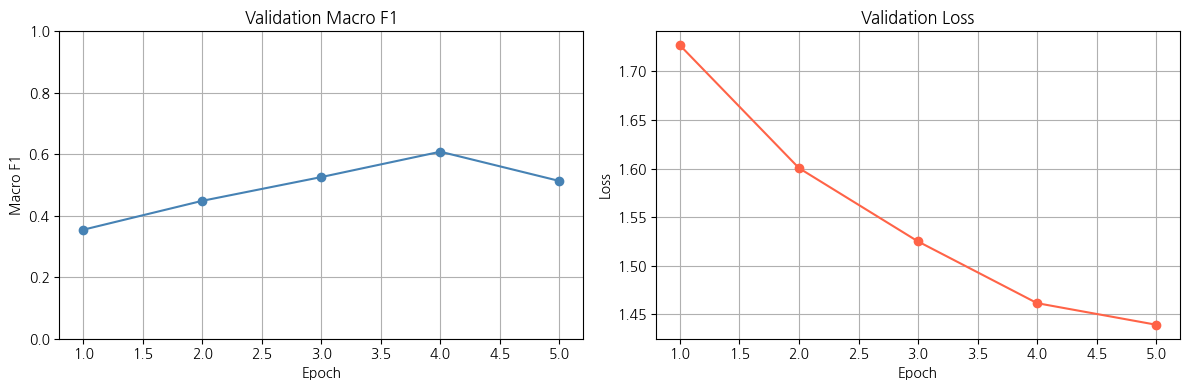

학습 곡선 저장 완료


In [9]:
# ── 8. 학습 곡선 시각화 ───────────────────────────────────────
import os, subprocess, matplotlib, matplotlib.font_manager as fm
import matplotlib.pyplot as plt
if os.path.exists('/content'):  # Colab 한글 폰트 자동 설치
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    fm.fontManager.__init__()
    _fp = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt

epochs_list = [h["epoch"] for h in history]
val_f1_list = [h["val_f1"] for h in history]
val_loss_list = [h["val_loss"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_list, val_f1_list, marker="o", color="steelblue")
axes[0].set_title("Validation Macro F1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(0, 1)
axes[0].grid(True)

axes[1].plot(epochs_list, val_loss_list, marker="o", color="tomato")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.savefig(CKPT_DIR / "training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("학습 곡선 저장 완료")

In [10]:
# ── 9. Test 세트 최종 평가 ────────────────────────────────────
# Best 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(CKPT_DIR)
model.to(DEVICE)
model.eval()

all_preds, all_trues = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels_tensor  = batch["labels"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_trues.extend(labels_tensor.cpu().tolist())

pred_labels_str = [ID2LABEL[p] for p in all_preds]
true_labels_str = [ID2LABEL[t] for t in all_trues]

print("[Test] 분류 리포트")
print(classification_report(true_labels_str, pred_labels_str, labels=LABELS, zero_division=0))

test_f1 = f1_score(true_labels_str, pred_labels_str, labels=LABELS, average="macro", zero_division=0)
print(f"[Test] Macro F1: {test_f1:.4f}")

# JSON으로 결과 저장
from sklearn.metrics import confusion_matrix, precision_score, recall_score
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=LABELS)
from sklearn.metrics import classification_report as _cr
_report = _cr(true_labels_str, pred_labels_str, labels=LABELS, output_dict=True, zero_division=0)
test_result = {
    "model": "kcelectra",
    "macro_f1": round(test_f1, 4),
    "macro_precision": round(precision_score(true_labels_str, pred_labels_str, labels=LABELS, average="macro", zero_division=0), 4),
    "macro_recall": round(recall_score(true_labels_str, pred_labels_str, labels=LABELS, average="macro", zero_division=0), 4),
    "per_class": {
        label: {
            "precision": round(_report[label]["precision"], 4),
            "recall":    round(_report[label]["recall"], 4),
            "f1":        round(_report[label]["f1-score"], 4),
            "support":   _report[label]["support"],
        }
        for label in LABELS if label in _report
    },
    "confusion_matrix": cm.tolist(),
    "labels": LABELS,
}
if _IN_COLAB:
    result_path = BASE_DIR / "eval_results_kcelectra_v1_2_20260430.json"
else:
    result_path = BASE_DIR / "data" / "20260430" / "eval_results_kcelectra_v1_2_20260430.json"
    result_path.parent.mkdir(parents=True, exist_ok=True)
with open(result_path, "w", encoding="utf-8") as f:
    json.dump(test_result, f, ensure_ascii=False, indent=2)
print(f"결과 저장: {result_path}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[Test] 분류 리포트
              precision    recall  f1-score   support

          일정       1.00      1.00      1.00         5
         준비물       0.67      0.50      0.57         4
          제출       0.00      0.00      0.00         4
          비용       0.33      1.00      0.50         2
       건강·안전       0.62      0.83      0.71         6
          기타       0.50      0.33      0.40         3

    accuracy                           0.62        24
   macro avg       0.52      0.61      0.53        24
weighted avg       0.57      0.62      0.57        24

[Test] Macro F1: 0.5310
결과 저장: /content/eval_results_kcelectra_v1_2_20260430.json


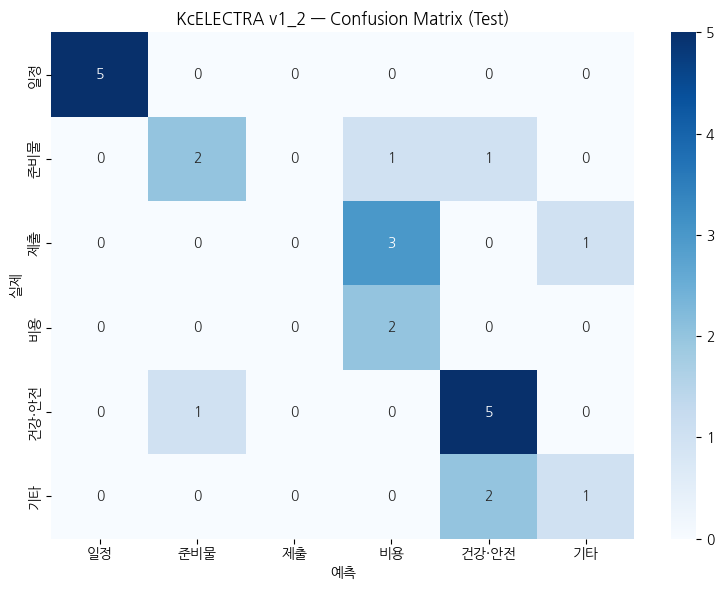

완료! 체크포인트 폴더를 다운로드하여 model/classification/checkpoints/kcelectra-category-v1_2/ 에 넣으세요.


In [11]:
# ── 10. Confusion Matrix 시각화 ───────────────────────────────
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cmap="Blues",
    ax=ax,
)
ax.set_title("KcELECTRA v1_2 — Confusion Matrix (Test)")
ax.set_xlabel("예측")
ax.set_ylabel("실제")
plt.tight_layout()
plt.savefig(CKPT_DIR / "confusion_matrix_kcelectra.png", dpi=150, bbox_inches="tight")
plt.show()
print("완료! 체크포인트 폴더를 다운로드하여 model/classification/checkpoints/kcelectra-category-v1_2/ 에 넣으세요.")

In [12]:
# ── 11. 체크포인트 다운로드 안내 (Colab 전용) ────────────────
import os
if os.path.exists('/content'):
    print(f'체크포인트 위치: {CKPT_DIR}')
    print()
    print('방법 A — 파일 패널에서 직접 다운로드:')
    print('  왼쪽 폴더 아이콘 → kcelectra-category-v1_2 폴더 우클릭 → 다운로드')
    print()
    print('방법 B — Google Drive로 저장 (세션 종료 후에도 유지):')
    print('  from google.colab import drive')
    print('  drive.mount("/drive")')
    print('  import shutil')
    print('  shutil.copytree(str(CKPT_DIR), "/drive/MyDrive/kcelectra-category-v1_2", dirs_exist_ok=True)')
    print()
    print('다운로드 후 로컬 경로에 붙여넣기:')
    print('  model/classification/checkpoints/kcelectra-category-v1_2/')
else:
    print(f'로컬 실행 완료. 체크포인트: {CKPT_DIR.resolve()}')

체크포인트 위치: /content/kcelectra-category-v1_2

방법 A — 파일 패널에서 직접 다운로드:
  왼쪽 폴더 아이콘 → kcelectra-category-v1_2 폴더 우클릭 → 다운로드

방법 B — Google Drive로 저장 (세션 종료 후에도 유지):
  from google.colab import drive
  drive.mount("/drive")
  import shutil
  shutil.copytree(str(CKPT_DIR), "/drive/MyDrive/kcelectra-category-v1_2", dirs_exist_ok=True)

다운로드 후 로컬 경로에 붙여넣기:
  model/classification/checkpoints/kcelectra-category-v1_2/


In [13]:
import shutil
shutil.make_archive("/content/kcelectra-category-v1_2", "zip", "/content/kcelectra-category-v1_2")
print("압축 완료!")

압축 완료!
